Step-1 Importing Library

In [39]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Step-2 Dataset Loading

In [21]:
from google.colab import files

uploaded = files.upload()

Saving agricultural_irrigation_1000_samples.csv to agricultural_irrigation_1000_samples (2).csv


here we used a agricultural irrigation 1000 sample.csv as a dataset .



In [25]:
import pandas as pd

df = pd.read_csv("agricultural_irrigation_1000_samples.csv")

df.head()


,soil_moisture,temperature,humidity,rainfall,nitrogen,phosphorus,potassium,ph,irrigation_needed
0,41.22,22.44,47.01,16.82,77.20,37.55,70.10,5.14,1
1,81.55,31.01,46.05,19.92,100.54,43.14,29.65,5.65,0
2,66.24,38.95,88.91,6.26,96.02,69.82,89.15,7.91,0
3,56.91,35.57,46.22,15.62,35.39,33.80,67.11,7.68,1
4,25.92,37.36,47.68,14.29,34.92,70.88,28.36,6.23,1


Step 3 — Understand your dataset

In [26]:
df.shape

(1000, 9)

1000 rows

9 columns

In [27]:
df.columns


Index(['soil_moisture', 'temperature', 'humidity', 'rainfall', 'nitrogen',
       'phosphorus', 'potassium', 'ph', 'irrigation_needed'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   soil_moisture      1000 non-null   float64
 1   temperature        1000 non-null   float64
 2   humidity           1000 non-null   float64
 3   rainfall           1000 non-null   float64
 4   nitrogen           1000 non-null   float64
 5   phosphorus         1000 non-null   float64
 6   potassium          1000 non-null   float64
 7   ph                 1000 non-null   float64
 8   irrigation_needed  1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [29]:
df.describe()

,soil_moisture,temperature,humidity,rainfall,nitrogen,phosphorus,potassium,ph,irrigation_needed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.317880,30.168420,62.656490,12.259360,69.410500,44.892400,56.931280,6.688210,0.381000
std,20.449611,7.012539,18.893683,7.162324,28.681043,20.243767,24.627307,0.997189,0.485876
min,15.320000,18.080000,30.000000,0.020000,20.000000,10.430000,15.120000,5.000000,0.000000
25%,31.520000,23.787500,46.987500,6.047500,44.495000,27.455000,35.417500,5.827500,0.000000
50%,49.780000,30.450000,62.540000,12.105000,69.460000,44.330000,56.195000,6.690000,0.000000
75%,67.105000,36.252500,79.345000,18.442500,94.002500,61.790000,79.300000,7.500000,1.000000
max,84.980000,41.990000,94.860000,24.990000,119.770000,79.950000,99.950000,8.500000,1.000000


"First, I loaded and explored the agricultural dataset to understand its dimensions, features, and statistical properties."

Step 4 — Separate Input and Output

Our input features are:

soil_moisture

temperature

humidity

rainfall

nitrogen

phosphorus

potassium

ph

Our output is:

irrigation_needed

In [31]:
X = df.drop("irrigation_needed", axis=1)

y = df["irrigation_needed"]

In [32]:
print(X.shape)
print(y.shape)

(1000, 8)
(1000,)


1000 samples and 8 input features.


Step 5 — Split the Dataset

We don't train the model using all the data.

We divide it into:

Training data → 80%

Testing data  → 20%

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

I divided the dataset into training and testing data. The model learns from the training data and its performance is evaluated using unseen testing data.

Step 6 — Feature Scaling

Temperature → 18–42

Humidity → 30–95

Rainfall → 0–25

Nitrogen → 20–120

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Training

In [36]:
scaler.fit_transform(X_train)

array([[-1.53413654,  1.07727001,  0.50739649, ..., -1.28935536,
        -1.35363774, -1.16783134],
       [ 1.53587954, -1.34466459,  1.12956271, ..., -1.34745939,
        -0.84006406,  0.78838199],
       [ 0.39389996, -1.52888013,  0.04050595, ..., -0.64630484,
         0.84889668,  0.7068731 ],
       ...,
       [ 0.95781035,  0.89733855,  1.2422971 , ..., -0.14729372,
        -1.45448935, -1.51424412],
       [ 0.70295215, -1.66025866, -0.40724102, ...,  0.82387369,
         0.23325631,  1.49139616],
       [-0.61869759,  1.26576964, -1.20754885, ...,  0.24722778,
        -0.60312353,  1.71554561]])

Testing

In [37]:
scaler.transform(X_test)

array([[-0.39118049,  1.43998899, -1.28890905, ...,  0.26919989,
        -0.97291278,  0.09555644],
       [ 1.09793354, -1.09618781,  0.12824734, ..., -0.7942504 ,
        -1.6885947 , -0.96405912],
       [-0.11142235,  1.07298593, -0.48966475, ...,  1.34143903,
        -1.11305196,  0.44196921],
       ...,
       [-1.67572443, -0.82486259, -0.7438489 , ...,  1.26819865,
        -0.31717478, -0.34255384],
       [-1.41354272, -0.65207126,  0.80731251, ..., -0.86749078,
        -1.57680737, -0.29161079],
       [-0.46783325, -1.01479024,  1.65069339, ..., -0.05159296,
         0.19761398,  0.27895144]])

Feature scaling brings different input features to a comparable numerical scale, which helps the neural network train more efficiently.

Step 7 — Create the Feedforward Neural Network

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation="relu", input_shape=(8,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


First layer

In [43]:
Dense(16, activation="relu", input_shape=(8,))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense_14, built=False>

8 input features

       ↓
16 neurons

Second layer

In [44]:
Dense(8, activation="relu")

<Dense name=dense_15, built=False>

16 neurons

     ↓
8 neurons

In [45]:
Dense(1, activation="sigmoid")

<Dense name=dense_16, built=False>

Output:

0 → Irrigation not needed

1 → Irrigation needed

Step 8 — Compile the Model

In [46]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Optimizer
Adam

Adam updates the neural network weights during training.

Loss
Binary Crossentropy

We use it because our output has two classes:

0

1

Metric
Accuracy

It tells us how many predictions are correct.

Step 9 — See the Network

In [47]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

Step 10 — Train the Neural Network


In [48]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4266 - loss: 0.7379 - val_accuracy: 0.4812 - val_loss: 0.7261
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5422 - loss: 0.6892 - val_accuracy: 0.5875 - val_loss: 0.6870
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6359 - loss: 0.6532 - val_accuracy: 0.6313 - val_loss: 0.6529
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6922 - loss: 0.6212 - val_accuracy: 0.6625 - val_loss: 0.6226
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7344 - loss: 0.5903 - val_accuracy: 0.6938 - val_loss: 0.5899
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7484 - loss: 0.5579 - val_accuracy: 0.7312 - val_loss: 0.5571
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7797 - loss: 0.5252 - val_accuracy: 0.7875 - val_loss: 0.5218
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8203 - loss: 0.4899 - val_accuracy: 0.8125 - v

epochs = 50

Instead of processing all 800 samples at once, the network processes:

What is batch size?

Instead of processing all 800 samples at once, the network processes:

32 samples at a time

Step 11 — Test the Model

In [49]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.2382  
Test Accuracy: 0.9100000262260437
Test Loss: 0.23821762204170227


Step 12 — Make Predictions

In [50]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [52]:
predicted_classes = (predictions > 0.5).astype(int)

Step 13 — Confusion Matrix

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

print(cm)

[[109  11]
 [  7  73]]


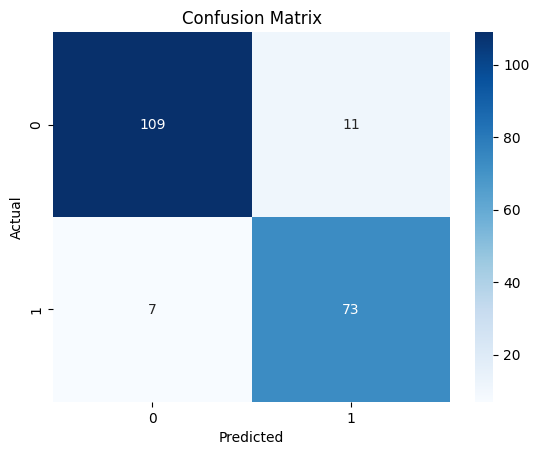

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows how many irrigation decisions were correctly and incorrectly classified.

Step 14 — Accuracy, Precision, Recall

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       120
           1       0.87      0.91      0.89        80

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



Precision

Of the fields predicted as needing irrigation, how many actually needed irrigation?

Recall

Of all fields that actually needed irrigation, how many did the model correctly identify?

F1-score

A combined measure of precision and recall.

Step 15 — Plot Training Accuracy

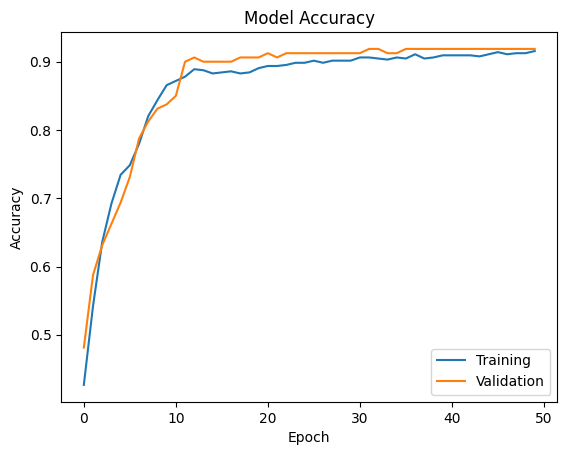

In [56]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

The history variable contains training information.

plot loss

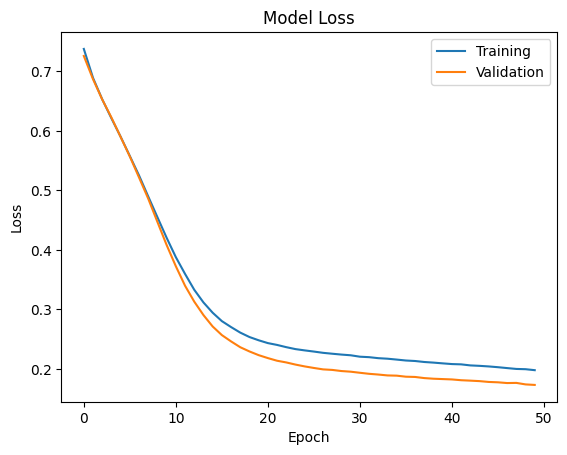

In [57]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

Step 16 — Test One New Agricultural Field

Suppose a farmer gives:

Soil moisture = 25

Temperature = 35

Humidity = 45

Rainfall = 2

Nitrogen = 50

Phosphorus = 40

Potassium = 60

pH = 6.5

In [58]:
new_field = np.array([[
    25,
    35,
    45,
    2,
    50,
    40,
    60,
    6.5
]])

In [59]:
new_field_scaled = scaler.transform(new_field)

In [60]:
prediction = model.predict(new_field_scaled)

print("Prediction probability:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction probability: 0.0


In [61]:
if prediction[0][0] >= 0.5:
    print("Irrigation is needed")
else:
    print("Irrigation is not needed")

Irrigation is not needed


Our Complete Workflow

            CSV DATASET
                   ↓
            Load Dataset
                   ↓
          Understand Dataset
                   ↓
        Separate X and y
                   ↓
          Train/Test Split
                   ↓
           Feature Scaling
                   ↓
       Create Neural Network
                   ↓
              Compile
                   ↓
               Train
                   ↓
               Evaluate
                   ↓
              Predict
                   ↓
       Confusion Matrix / Accuracy
                   ↓
       New Field Prediction

Conclusion:

A feedforward neural network was successfully implemented using TensorFlow to predict irrigation requirements in an agricultural field. The model used soil and environmental parameters such as soil moisture, temperature, humidity, rainfall, NPK values and pH. The dataset was divided into training and testing sets, features were standardized, and the neural network was trained using the Adam optimizer and binary crossentropy loss. The model was evaluated using accuracy and classification metrics and was also used to predict irrigation requirements for a new field.